# S08-09. PyTorch 101 b основы оптимизации обучения. MLP b регуляризация (Dropout, BatchNorm, EarlyStopping). Learning rate диагностика, Adam vs SGD+momentum, weight decay.

## 2.3.1. Импорты, seed и устройство

In [22]:
import random
import numpy as np
import pandas as pd
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import random_split, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import json

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)

device: cpu
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


## 2.3.2. Данные и DataLoader

In [4]:
#1) Определить transform (минимум ToTensor(), нормализация – по желанию).
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
#2) Загрузить выбранный датасет через torchvision.datasets.*.
train_dataset_full = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)
#3) Сделать разбиение train/val из train-части с фиксированным seed.
val_ratio = 0.2
val_size = int(len(train_dataset_full) * val_ratio)
train_size = len(train_dataset_full) - val_size
generator = torch.Generator()
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=generator)
#4) Создать `DataLoader` для train/val/test.  
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
#5) Показать sanity-check: размеры батча, shapes (`x.shape`, `y.shape`), диапазоны значений.
for x, y in train_loader:
    print(f"Batch x shape: {x.shape}, y shape: {y.shape}")
    print(f"x min: {x.min():.3f}, max: {x.max():.3f}")
    break

Batch x shape: torch.Size([128, 1, 28, 28]), y shape: torch.Size([128])
x min: -1.000, max: 1.000


## 2.3.3. Модель MLP и цикл обучения

In [5]:
# 1) Реализовать MLP как `nn.Module` (Flatten, Linear, …, logits).
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        layers = [nn.Flatten()]

        prev = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [6]:
'''
2) Выбрать:
    - loss: `CrossEntropyLoss`;
    - optimizer: `Adam` (по умолчанию для базовых экспериментов);
    - метрика: accuracy (достаточно).  
'''
criterion = nn.CrossEntropyLoss()
#optimizer Adam будем применять уже напрямую к моделям
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

In [7]:
'''
3) Реализовать функции (или эквивалент):
    - `train_one_epoch(...)`
    - `evaluate(...)` (с `model.eval()` и `torch.no_grad()`)  
'''
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


In [8]:
# 4) Логировать историю обучения: train/val loss и train/val accuracy по эпохам.
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

## 3.1. Часть A (S08): регуляризация и переобучение

Задача: показать эффект Dropout/BatchNorm и ранней остановки.

In [9]:
# Для начала, определим общие параметры для экспериментов части А
EPOCHS_A = 20
LR = 1e-3
HIDDEN_DIMS = (512, 256, 128)
experiments = {}

In [10]:
# E1 (base): MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.
model_e1 = MLP(
    hidden_dims=HIDDEN_DIMS
).to(device)

optimizer_e1 = optim.Adam(model_e1.parameters(), lr=LR)

history_e1 = fit(
    model_e1, train_loader, val_loader,
    optimizer_e1, criterion, device,
    epochs=EPOCHS_A,
    early_stopping=None,
    verbose=True
)

best_val_acc_e1 = max(history_e1['val_acc'])
best_val_loss_e1 = min(history_e1['val_loss'])
experiments['E1'] = {
    'model': model_e1,
    'history': history_e1,
    'best_val_acc': best_val_acc_e1,
    'best_val_loss': best_val_loss_e1,
    'config': {
        'hidden_dims': HIDDEN_DIMS,
        'activation': 'relu',
        'dropout_p': 0.0,
        'use_batchnorm': False,
        'optimizer': 'Adam',
        'lr': LR,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs_trained': len(history_e1['val_acc'])
    }
}
print(f"E1 best val acc: {best_val_acc_e1:.4f}, loss: {best_val_loss_e1:.4f}\n")

epoch 01/20 | train loss=1.2335, acc=0.6376 | val loss=0.7681, acc=0.7591
epoch 02/20 | train loss=0.6618, acc=0.7850 | val loss=0.6338, acc=0.7875
epoch 03/20 | train loss=0.5471, acc=0.8157 | val loss=0.5590, acc=0.8148
epoch 04/20 | train loss=0.4846, acc=0.8326 | val loss=0.5223, acc=0.8268
epoch 05/20 | train loss=0.4440, acc=0.8449 | val loss=0.4989, acc=0.8339
epoch 06/20 | train loss=0.4086, acc=0.8536 | val loss=0.5043, acc=0.8309
epoch 07/20 | train loss=0.3862, acc=0.8607 | val loss=0.4979, acc=0.8351
epoch 08/20 | train loss=0.3638, acc=0.8658 | val loss=0.4866, acc=0.8407
epoch 09/20 | train loss=0.3452, acc=0.8712 | val loss=0.4854, acc=0.8370
epoch 10/20 | train loss=0.3271, acc=0.8764 | val loss=0.5116, acc=0.8318
epoch 11/20 | train loss=0.3088, acc=0.8820 | val loss=0.5241, acc=0.8363
epoch 12/20 | train loss=0.2976, acc=0.8851 | val loss=0.4998, acc=0.8402
epoch 13/20 | train loss=0.2860, acc=0.8882 | val loss=0.5295, acc=0.8413
epoch 14/20 | train loss=0.2725, acc=0

In [11]:
# E2 (Dropout): как E1, но добавить Dropout (например, p=0.2-0.5).
model_e2 = MLP(
    input_dim=28*28,
    hidden_dims=HIDDEN_DIMS,
    num_classes=47,
    activation="relu",
    dropout_p=0.3,
    use_batchnorm=False
).to(device)

optimizer_e2 = optim.Adam(model_e2.parameters(), lr=LR)

history_e2 = fit(
    model_e2, train_loader, val_loader,
    optimizer_e2, criterion, device,
    epochs=EPOCHS_A,
    early_stopping=None,
    verbose=True
)

best_val_acc_e2 = max(history_e2['val_acc'])
best_val_loss_e2 = min(history_e2['val_loss'])
experiments['E2'] = {
    'model': model_e2,
    'history': history_e2,
    'best_val_acc': best_val_acc_e2,
    'best_val_loss': best_val_loss_e2,
    'config': {
        'hidden_dims': HIDDEN_DIMS,
        'activation': 'relu',
        'dropout_p': 0.3,
        'use_batchnorm': False,
        'optimizer': 'Adam',
        'lr': LR,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs_trained': len(history_e2['val_acc'])
    }
}
print(f"E2 best val acc: {best_val_acc_e2:.4f}, loss: {best_val_loss_e2:.4f}\n")

epoch 01/20 | train loss=1.6297, acc=0.5236 | val loss=0.8707, acc=0.7251
epoch 02/20 | train loss=0.9826, acc=0.6950 | val loss=0.6876, acc=0.7777
epoch 03/20 | train loss=0.8557, acc=0.7310 | val loss=0.6127, acc=0.8024
epoch 04/20 | train loss=0.7912, acc=0.7473 | val loss=0.5962, acc=0.8037
epoch 05/20 | train loss=0.7483, acc=0.7570 | val loss=0.5506, acc=0.8181
epoch 06/20 | train loss=0.7141, acc=0.7710 | val loss=0.5425, acc=0.8213
epoch 07/20 | train loss=0.6959, acc=0.7746 | val loss=0.5239, acc=0.8253
epoch 08/20 | train loss=0.6714, acc=0.7808 | val loss=0.5192, acc=0.8231
epoch 09/20 | train loss=0.6592, acc=0.7829 | val loss=0.5071, acc=0.8273
epoch 10/20 | train loss=0.6459, acc=0.7890 | val loss=0.4983, acc=0.8325
epoch 11/20 | train loss=0.6375, acc=0.7890 | val loss=0.4967, acc=0.8311
epoch 12/20 | train loss=0.6263, acc=0.7933 | val loss=0.4912, acc=0.8338
epoch 13/20 | train loss=0.6208, acc=0.7942 | val loss=0.4905, acc=0.8377
epoch 14/20 | train loss=0.6060, acc=0

In [13]:
# E3 (BatchNorm): как E1, но добавить BatchNorm (между Linear и активацией).
model_e3 = MLP(
    input_dim=28*28,
    hidden_dims=HIDDEN_DIMS,
    num_classes=47,
    activation="relu",
    dropout_p=0.0,
    use_batchnorm=True
).to(device)

optimizer_e3 = optim.Adam(model_e3.parameters(), lr=LR)

history_e3 = fit(
    model_e3, train_loader, val_loader,
    optimizer_e3, criterion, device,
    epochs=EPOCHS_A,
    early_stopping=None,
    verbose=True
)

best_val_acc_e3 = max(history_e3['val_acc'])
best_val_loss_e3 = min(history_e3['val_loss'])
experiments['E3'] = {
    'model': model_e3,
    'history': history_e3,
    'best_val_acc': best_val_acc_e3,
    'best_val_loss': best_val_loss_e3,
    'config': {
        'hidden_dims': HIDDEN_DIMS,
        'activation': 'relu',
        'dropout_p': 0.0,
        'use_batchnorm': True,
        'optimizer': 'Adam',
        'lr': LR,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs_trained': len(history_e3['val_acc'])
    }
}
print(f"E3 best val acc: {best_val_acc_e3:.4f}, loss: {best_val_loss_e3:.4f}\n")

epoch 01/20 | train loss=0.8985, acc=0.7473 | val loss=0.5541, acc=0.8175
epoch 02/20 | train loss=0.4877, acc=0.8337 | val loss=0.4828, acc=0.8351
epoch 03/20 | train loss=0.4083, acc=0.8551 | val loss=0.4662, acc=0.8411
epoch 04/20 | train loss=0.3628, acc=0.8691 | val loss=0.4451, acc=0.8477
epoch 05/20 | train loss=0.3289, acc=0.8782 | val loss=0.4442, acc=0.8523
epoch 06/20 | train loss=0.3008, acc=0.8867 | val loss=0.4486, acc=0.8524
epoch 07/20 | train loss=0.2783, acc=0.8920 | val loss=0.4438, acc=0.8500
epoch 08/20 | train loss=0.2593, acc=0.8993 | val loss=0.4444, acc=0.8554
epoch 09/20 | train loss=0.2410, acc=0.9044 | val loss=0.4717, acc=0.8460
epoch 10/20 | train loss=0.2285, acc=0.9091 | val loss=0.4646, acc=0.8540
epoch 11/20 | train loss=0.2169, acc=0.9130 | val loss=0.4750, acc=0.8520
epoch 12/20 | train loss=0.2020, acc=0.9175 | val loss=0.5010, acc=0.8491
epoch 13/20 | train loss=0.1943, acc=0.9209 | val loss=0.4911, acc=0.8529
epoch 14/20 | train loss=0.1832, acc=0

In [15]:
# E4 (EarlyStopping): выбрать **лучший** из (E2/E3) по `val_accuracy` и обучить его с EarlyStopping (patience 3-5).
if experiments['E2']['best_val_acc'] >= experiments['E3']['best_val_acc']:
    best_reg_config = experiments['E2']['config'].copy()
    best_reg_config['dropout_p'] = 0.3
    best_reg_config['use_batchnorm'] = False
    print("Лучшая регуляризация: Dropout")
else:
    best_reg_config = experiments['E3']['config'].copy()
    best_reg_config['dropout_p'] = 0.0
    best_reg_config['use_batchnorm'] = True
    print("Лучшая регуляризация: BatchNorm")

best_arch_config = {k: best_reg_config[k] for k in ['hidden_dims', 'activation', 'dropout_p', 'use_batchnorm']}

model_e4 = MLP(
    input_dim=28*28,
    num_classes=47,
    **best_arch_config
).to(device)

optimizer_e4 = optim.Adam(model_e4.parameters(), lr=LR)
early_stopping = EarlyStopping(patience=4, min_delta=0.001)

history_e4 = fit(
    model_e4, train_loader, val_loader,
    optimizer_e4, criterion, device,
    epochs=50,
    early_stopping=early_stopping,
    verbose=True
)

best_val_acc_e4 = max(history_e4['val_acc'])
best_val_loss_e4 = min(history_e4['val_loss'])
experiments['E4'] = {
    'model': model_e4,
    'history': history_e4,
    'best_val_acc': best_val_acc_e4,
    'best_val_loss': best_val_loss_e4,
    'config': {
        'hidden_dims': best_arch_config['hidden_dims'],
        'activation': best_arch_config['activation'],
        'dropout_p': best_arch_config['dropout_p'],
        'use_batchnorm': best_arch_config['use_batchnorm'],
        'optimizer': 'Adam',
        'lr': LR,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs_trained': len(history_e4['val_acc'])
    }
}
print(f"E4 best val acc: {best_val_acc_e4:.4f}, loss: {best_val_loss_e4:.4f}")

Лучшая регуляризация: BatchNorm
epoch 01/50 | train loss=0.9012, acc=0.7490 | val loss=0.5622, acc=0.8171
epoch 02/50 | train loss=0.4911, acc=0.8340 | val loss=0.4771, acc=0.8392
epoch 03/50 | train loss=0.4102, acc=0.8550 | val loss=0.4642, acc=0.8438
epoch 04/50 | train loss=0.3628, acc=0.8681 | val loss=0.4383, acc=0.8528
epoch 05/50 | train loss=0.3306, acc=0.8771 | val loss=0.4450, acc=0.8490
epoch 06/50 | train loss=0.2999, acc=0.8863 | val loss=0.4407, acc=0.8534
epoch 07/50 | train loss=0.2789, acc=0.8924 | val loss=0.4460, acc=0.8530
epoch 08/50 | train loss=0.2610, acc=0.8982 | val loss=0.4497, acc=0.8524
EarlyStopping: остановка на эпохе 8. Лучший val_acc=0.8528
E4 best val acc: 0.8534, loss: 0.4383


## 3.2. Часть B (S09): LR, оптимизаторы, weight decay

In [16]:
# O1 (LR слишком большой): Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.
model_o1 = MLP(input_dim=28*28, num_classes=47, **best_arch_config).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)

history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer_o1, criterion, device,
    epochs=8,
    early_stopping=None,
    verbose=True
)

best_val_acc_o1 = max(history_o1['val_acc']) if history_o1['val_acc'] else float('nan')
best_val_loss_o1 = min(history_o1['val_loss']) if history_o1['val_loss'] else float('nan')
experiments['O1'] = {
    'model': model_o1,
    'history': history_o1,
    'best_val_acc': best_val_acc_o1,
    'best_val_loss': best_val_loss_o1,
    'config': {
        **best_arch_config,
        'optimizer': 'Adam',
        'lr': 1e-1,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs_trained': len(history_o1['val_acc'])
    }
}

epoch 01/8 | train loss=1.0790, acc=0.6701 | val loss=0.8077, acc=0.7406
epoch 02/8 | train loss=0.7457, acc=0.7594 | val loss=0.6978, acc=0.7850
epoch 03/8 | train loss=0.6454, acc=0.7876 | val loss=0.6551, acc=0.7931
epoch 04/8 | train loss=0.5963, acc=0.8035 | val loss=0.5961, acc=0.8119
epoch 05/8 | train loss=0.5639, acc=0.8117 | val loss=0.6225, acc=0.8076
epoch 06/8 | train loss=0.5451, acc=0.8195 | val loss=0.6348, acc=0.8023
epoch 07/8 | train loss=0.5115, acc=0.8262 | val loss=0.6043, acc=0.8175
epoch 08/8 | train loss=0.4968, acc=0.8319 | val loss=0.5858, acc=0.8144


In [17]:
# O2 (LR слишком маленький): Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.
model_o2 = MLP(input_dim=28*28, num_classes=47, **best_arch_config).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer_o2, criterion, device,
    epochs=8,
    early_stopping=None,
    verbose=True
)

best_val_acc_o2 = max(history_o2['val_acc'])
best_val_loss_o2 = min(history_o2['val_loss'])
experiments['O2'] = {
    'model': model_o2,
    'history': history_o2,
    'best_val_acc': best_val_acc_o2,
    'best_val_loss': best_val_loss_o2,
    'config': {
        **best_arch_config,
        'optimizer': 'Adam',
        'lr': 1e-5,
        'weight_decay': 0.0,
        'momentum': None,
        'epochs_trained': len(history_o2['val_acc'])
    }
}

epoch 01/8 | train loss=3.3208, acc=0.2519 | val loss=2.9183, acc=0.4173
epoch 02/8 | train loss=2.6990, acc=0.4902 | val loss=2.4931, acc=0.5484
epoch 03/8 | train loss=2.3361, acc=0.5854 | val loss=2.1784, acc=0.6137
epoch 04/8 | train loss=2.0570, acc=0.6396 | val loss=1.9310, acc=0.6560
epoch 05/8 | train loss=1.8270, acc=0.6728 | val loss=1.7237, acc=0.6819
epoch 06/8 | train loss=1.6357, acc=0.6989 | val loss=1.5622, acc=0.7040
epoch 07/8 | train loss=1.4750, acc=0.7187 | val loss=1.4082, acc=0.7201
epoch 08/8 | train loss=1.3400, acc=0.7351 | val loss=1.2888, acc=0.7328


In [ ]:
# O3 (SGD+momentum + weight decay)**: SGD с momentum (например, momentum=0.9) и **weight_decay > 0** (например, 1e-4).
model_o3 = MLP(input_dim=28*28, num_classes=47, **best_arch_config).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

history_o3 = fit(
    model_o3, train_loader, val_loader,
    optimizer_o3, criterion, device,
    epochs=12,
    early_stopping=None,
    verbose=True
)

best_val_acc_o3 = max(history_o3['val_acc'])
best_val_loss_o3 = min(history_o3['val_loss'])
experiments['O3'] = {
    'model': model_o3,
    'history': history_o3,
    'best_val_acc': best_val_acc_o3,
    'best_val_loss': best_val_loss_o3,
    'config': {
        **best_arch_config,
        'optimizer': 'SGD',
        'lr': 1e-2,
        'weight_decay': 1e-4,
        'momentum': 0.9,
        'epochs_trained': len(history_o3['val_acc'])
    }
}

epoch 01/12 | train loss=1.0088, acc=0.7262 | val loss=0.5988, acc=0.8030
epoch 02/12 | train loss=0.5174, acc=0.8274 | val loss=0.5058, acc=0.8303
epoch 03/12 | train loss=0.4275, acc=0.8522 | val loss=0.4706, acc=0.8434
epoch 04/12 | train loss=0.3768, acc=0.8675 | val loss=0.4534, acc=0.8468
epoch 05/12 | train loss=0.3434, acc=0.8770 | val loss=0.4434, acc=0.8462
epoch 06/12 | train loss=0.3114, acc=0.8870 | val loss=0.4412, acc=0.8497
epoch 07/12 | train loss=0.2887, acc=0.8919 | val loss=0.4419, acc=0.8504
epoch 08/12 | train loss=0.2700, acc=0.8975 | val loss=0.4397, acc=0.8532
epoch 09/12 | train loss=0.2510, acc=0.9043 | val loss=0.4511, acc=0.8473
epoch 10/12 | train loss=0.2356, acc=0.9087 | val loss=0.4526, acc=0.8505
epoch 11/12 | train loss=0.2204, acc=0.9137 | val loss=0.4543, acc=0.8521
epoch 12/12 | train loss=0.2104, acc=0.9168 | val loss=0.4703, acc=0.8486


## 4. Сохранение артефактов

In [24]:
# 1 `runs.csv` – таблица результатов по всем экспериментам E1-E4 и O1-O3 (по одной строке на эксперимент).
rows = []
for exp_id, data in experiments.items():
    cfg = data['config']
    rows.append({
        "experiment_id": exp_id,
        "dataset": "EMNIST_balanced",
        "seed": SEED,
        "model_summary": (f"hidden={cfg['hidden_dims']}, "
                          f"act={cfg['activation']}, "
                          f"dropout={cfg['dropout_p']}, "
                          f"bn={cfg['use_batchnorm']}"),
        "optimizer": cfg['optimizer'],
        "lr": cfg['lr'],
        "momentum": cfg.get('momentum', ''),
        "weight_decay": cfg.get('weight_decay', 0.0),
        "epochs_trained": cfg['epochs_trained'],
        "best_val_accuracy": data['best_val_acc'],
        "best_val_loss": data['best_val_loss']
    })

df_runs = pd.DataFrame(rows)
df_runs.to_csv("artifacts/runs.csv", index=False)
print("\nСводная таблица экспериментов:")
display(df_runs)


Сводная таблица экспериментов:


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST_balanced,42,"hidden=(512, 256, 128), act=relu, dropout=0.0,...",Adam,0.00100,NaN,0.0000,20,0.842161,0.485419
1,E2,EMNIST_balanced,42,"hidden=(512, 256, 128), act=relu, dropout=0.3,...",Adam,0.00100,NaN,0.0000,20,0.841322,0.471392
2,E3,EMNIST_balanced,42,"hidden=(512, 256, 128), act=relu, dropout=0.0,...",Adam,0.00100,NaN,0.0000,20,0.855932,0.443754
3,E4,EMNIST_balanced,42,"hidden=(512, 256, 128), act=relu, dropout=0.0,...",Adam,0.00100,NaN,0.0000,8,0.853416,0.438342
4,O1,EMNIST_balanced,42,"hidden=(512, 256, 128), act=relu, dropout=0.0,...",Adam,0.10000,NaN,0.0000,8,0.817532,0.585777
5,O2,EMNIST_balanced,42,"hidden=(512, 256, 128), act=relu, dropout=0.0,...",Adam,0.00001,NaN,0.0000,8,0.732786,1.288845
6,O3,EMNIST_balanced,42,"hidden=(512, 256, 128), act=relu, dropout=0.0,...",SGD,0.01000,0.9,0.0001,12,0.853151,0.439720


In [ ]:
# 2 `best_model.pt` – сохранённый `state_dict()` лучшей модели (E4).  
torch.save(model_e4.state_dict(), "artifacts/best_model.pt")

In [26]:
# 3 `best_config.json` – конфиг лучшей модели (архитектура, ключевые гиперпараметры обучения, seed, датасет).
best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST_balanced",
    "seed": SEED,
    "model": {
        "input_dim": 28*28,
        "num_classes": 47,
        "hidden_dims": best_arch_config['hidden_dims'],
        "activation": best_arch_config['activation'],
        "dropout_p": best_arch_config['dropout_p'],
        "use_batchnorm": best_arch_config['use_batchnorm']
    },
    "training": {
        "optimizer": "Adam",
        "lr": LR,
        "weight_decay": 0.0,
        "momentum": None,
        "batch_size": batch_size,
        "epochs_trained": len(history_e4['val_acc']),
        "early_stopping_patience": 4,
        "best_val_accuracy": best_val_acc_e4,
        "best_val_loss": best_val_loss_e4
    }
}

with open("artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

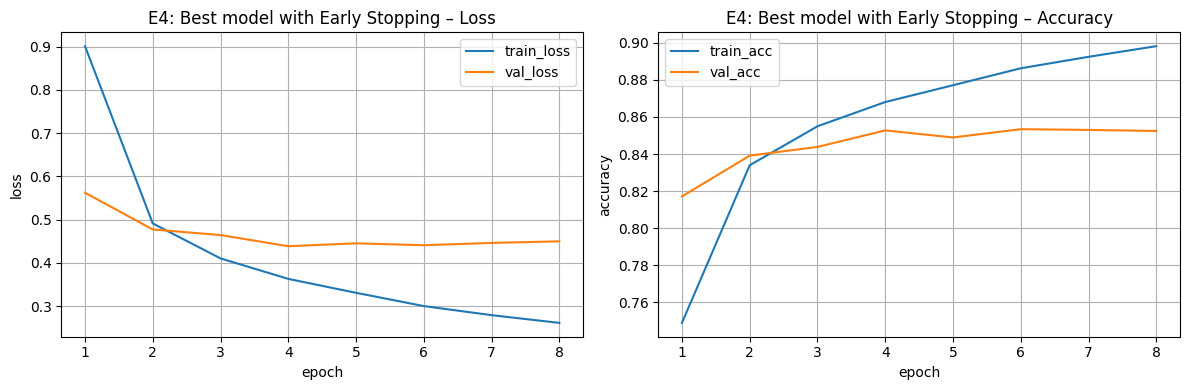

In [27]:
# 4 `figures/curves_best.png` – график train/val loss (или loss+accuracy) для лучшего прогона (E4).  
def plot_and_save(history, title, filename):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(f'{title} – Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='train_acc')
    plt.plot(epochs, history['val_acc'], label='val_acc')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title(f'{title} – Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

plot_and_save(
    experiments['E4']['history'],
    "E4: Best model with Early Stopping",
    "artifacts/figures/curves_best.png"
)

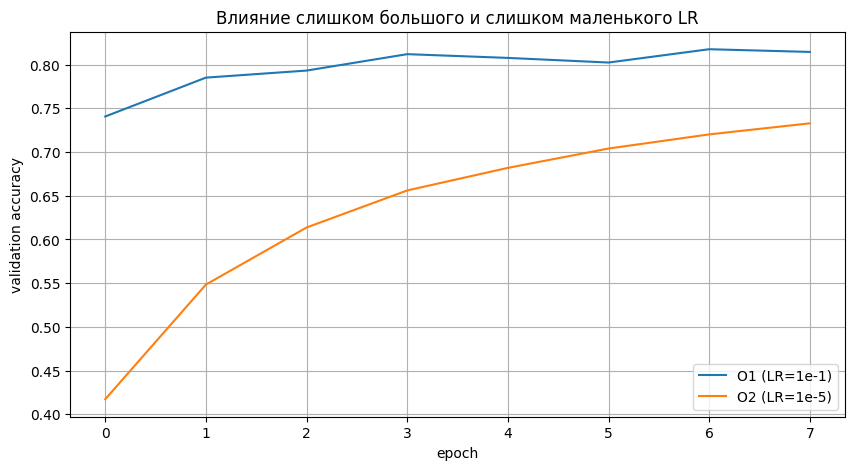

In [28]:
# 5 `figures/curves_lr_extremes.png` – график(и), показывающий(ие) поведение O1 и O2 (LR слишком большой/маленький). 
plt.figure(figsize=(10, 5))
plt.plot(experiments['O1']['history']['val_acc'], label='O1 (LR=1e-1)')
plt.plot(experiments['O2']['history']['val_acc'], label='O2 (LR=1e-5)')
plt.xlabel('epoch')
plt.ylabel('validation accuracy')
plt.title('Влияние слишком большого и слишком маленького LR')
plt.legend()
plt.grid(True)
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=150)
plt.show()

In [29]:
# Финальная оценка лучшей модели (E4) на test (один раз).
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Test loss: {test_loss:.4f}, test accuracy: {test_acc:.4f}")

Test loss: 0.4572, test accuracy: 0.8446
